In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# load the dataset
df = pd.read_csv("../Dataset/phishing.csv")

In [2]:
# understand the data
df.shape

(10000, 5)

In [3]:
# check columns
df.columns

Index(['text', 'label', 'phishing_type', 'severity', 'confidence'], dtype='object')

In [4]:
# check datatype
df.info

<bound method DataFrame.info of                                                    text  label  \
0     Subject: Office maintenance\n\nThanks for your...      0   
1     Hello, your profile has been locked. Use the s...      1   
2     Hi there, congratulations! You are the winner ...      1   
3     Attention, this is the fraud prevention accoun...      1   
4     Notice, your profile has been restricted. Use ...      1   
...                                                 ...    ...   
9995  Subject: Code review summary\n\nI booked the l...      0   
9996  Hello, we talked about meeting again after the...      1   
9997  Hi there, we talked about meeting again after ...      1   
9998  Dear user, this is an expires midnight notice ...      1   
9999  Subject: Conference registration\n\nThanks for...      0   

              phishing_type severity  confidence  
0                legitimate      low        0.95  
1     credential_harvesting     high        0.89  
2            financial

In [5]:
# statical summary
df.describe()

,label,confidence
count,10000.000000,10000.000000
mean,0.600000,0.898855
std,0.489922,0.083430
min,0.000000,0.650000
25%,0.000000,0.840000
50%,1.000000,0.920000
75%,1.000000,0.970000
max,1.000000,1.000000


In [6]:
# check for null values
df.isnull().sum()
# remove null if exist
# df.dropna(inplace=True)

text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

In [7]:
# check for duplicates
df.duplicated().sum()
# remove duplicates if exist
df.drop_duplicates(inplace=True)

In [8]:
# after removing duplicate check row will be reduced
# earlier there was 10000 rows but after removing duplicates it will be reduced to 9998 
df.shape

(9998, 5)

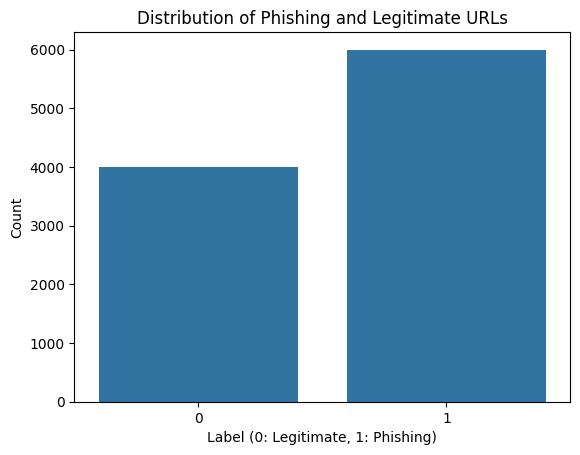

In [9]:
# Data Visualization
# Phishing vs Non-Phishing

sns.countplot(x='label', data=df)
plt.title('Distribution of Phishing and Legitimate URLs')
plt.xlabel('Label (0: Legitimate, 1: Phishing)')
plt.ylabel('Count')
plt.show()

Text Cleaning -

Computers cannot understand raw text like:

"URGENT!!! Click here now!!!"

We convert it into clean format.

In [10]:
# Install and import NLTK Data
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
# clean text function
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # split into words
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # join words again
    return " ".join(words)

What You Will See
Before :
"URGENT!!! Click here now!!!" ,
After :
urgent click

Why This Is Important

This step :
removes noise ,
improves ML accuracy ,
makes model smarter.

In [12]:
# Apply the cleaning function to the 'url' column
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks help analysi...
1,"Hello, your profile has been locked. Use the s...",hello profile locked use secure link verify us...
2,"Hi there, congratulations! You are the winner ...",hi congratulations winner refund collect gift ...
3,"Attention, this is the fraud prevention accoun...",attention fraud prevention accounts team secur...
4,"Notice, your profile has been restricted. Use ...",notice profile restricted use secure link rese...


👆 This means:

✔ Lowercase applied 

✔ Special characters removed 

✔ Stopwords removed 

✔ Text cleaned 

This step is called :   
Text Preprocessing

In [13]:
#Convert text into numerical features using TF-IDF Vectorizer 
# TF-IDF stands for Term Frequency-Inverse Document Frequency. It is a numerical representation of text data that reflects the importance of words in a document relative to a collection of documents (corpus). TF-IDF is commonly used in natural language processing (NLP) tasks, such as text classification, information retrieval, and text mining.

# Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
# Create Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

In [15]:
# Convert Clean Text to Numbers
X = vectorizer.fit_transform(df['clean_text'])

In [16]:
# Define Target (Label)
y_label = df['label']


In [18]:
# Check Shape
print("Type of X:", type(X))
print("Type of y:", type(y_label))
print("Shape of X:", X.shape)
print("Shape of y:", y_label.shape)

Type of X: <class 'scipy.sparse._csr.csr_matrix'>
Type of y: <class 'pandas.core.series.Series'>
Shape of X: (9998, 577)
Shape of y: (9998,)


In [19]:
# Encode phishing_type
from sklearn.preprocessing import LabelEncoder

type_encoder = LabelEncoder()

df['phishing_type_encoded'] = type_encoder.fit_transform(
    df['phishing_type']
)

df['phishing_type_encoded'].unique()
df['phishing_type_encoded'].value_counts()
# create target variable for phishing type
y_type = df['phishing_type_encoded']


In [20]:
# Print the mapping of encoded values to original labels
for i, label in enumerate(type_encoder.classes_):
    print(i, "=", label)

0 = authority_scam
1 = credential_harvesting
2 = financial_scam
3 = generic_phishing
4 = legitimate
5 = romance_dating
6 = social_engineering
7 = social_engineering_advanced
8 = tech_support
9 = threats
10 = urgency


In [21]:
# Encode severity
severity_encoder = LabelEncoder()

df['severity_encoded'] = severity_encoder.fit_transform(
    df['severity']
)

df[['severity', 'severity_encoded']].value_counts()
# create target variable for severity
y_severity = df['severity_encoded']

In [22]:
# Print the mapping of encoded values to original labels
for i, label in enumerate(severity_encoder.classes_):
    print(i, "=", label)

0 = high
1 = low
2 = medium


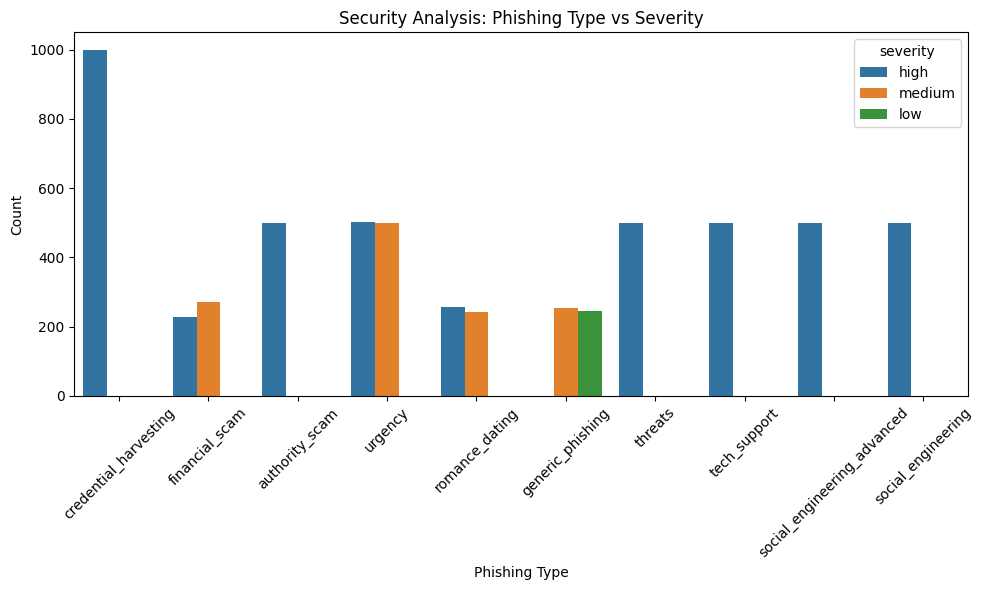

In [23]:
# Data Visualization
# Phishing Type vs Severity

# Filter only phishing
phishing_df = df[df['label'] == 1]

plt.figure(figsize=(10,6))

sns.countplot(
    data=phishing_df,
    x='phishing_type',
    hue='severity'
)

plt.xticks(rotation=45)

plt.title("Security Analysis: Phishing Type vs Severity")
plt.xlabel("Phishing Type")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

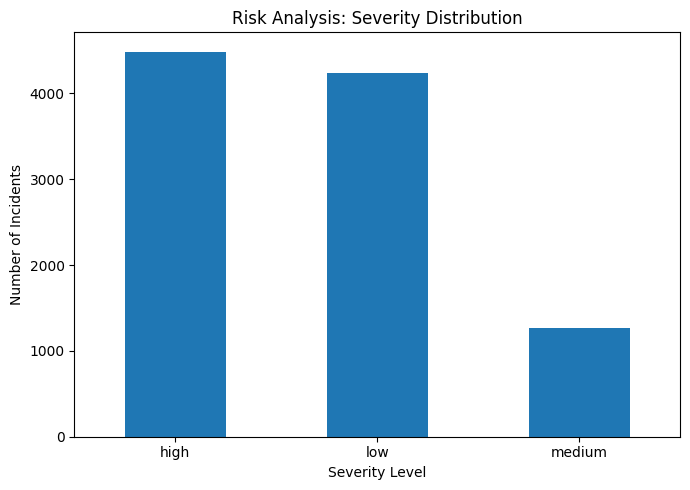

In [24]:
# Severity Distribution

plt.figure(figsize=(7,5))

df['severity'].value_counts().plot(kind='bar')

plt.title("Risk Analysis: Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

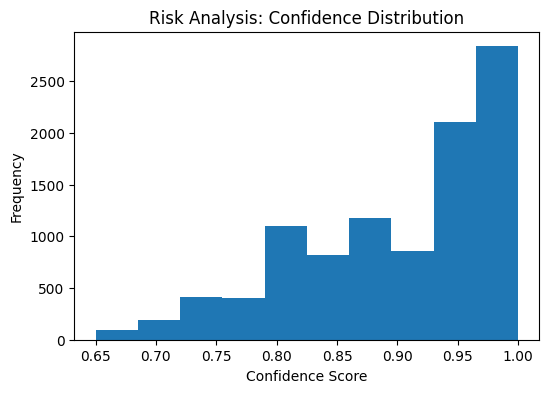

In [25]:
# Confidence Distribution

plt.figure(figsize=(6,4))

plt.hist(df['confidence'])

plt.title("Risk Analysis: Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.show()

After cleaning text and converting into numerical now we have to do ->
Train 3 models
1. Phishing detection model
2. Phishing type model
3. Severity prediction model

1. PHISHING DETECTION MODEL


Input  → clean_text (TF-IDF)       
Output → label (0 = Legitimate, 1 = Phishing)     
so    


In [56]:
# Step 1 — Split TEXT First
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train_text.shape[0])
print("Test size:", X_test_text.shape[0])

Train size: 7998
Test size: 2000


In [57]:
# Step 2 — Apply TF-IDF Correctly
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)

Step 3 — Train Phishing Detection Model

We use:

Multinomial Naive Bayes

Why?

Fast
Works best for text
Beginner-friendly
Industry standard baseline

In [58]:
from sklearn.naive_bayes import MultinomialNB

phishing_model = MultinomialNB()

phishing_model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [59]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = phishing_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Classification Report:\n",
    classification_report(y_test, y_pred)
)

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       797
           1       1.00      1.00      1.00      1203

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Still getting 100% accuracy lets check it

In [ ]:
# Step 1 — Most Common Real Cause: Text Contains Label Words

# Sometimes datasets contain patterns like:

# "this is a phishing email"
# "legitimate business message"

# Then the model just memorizes obvious keywords → 100% accuracy.

df.groupby('label')['clean_text'].count()

label
0    3998
1    6000
Name: clean_text, dtype: int64

In [ ]:
# Step 2 — Strong Diagnostic Test (Very Important)

# We will test the model on completely new text that was never in the dataset.

sample_texts = [
    "Hello team, please find attached meeting agenda",
    "Your bank account has been suspended. Click link to verify immediately"
]

sample_vectors = vectorizer.transform(sample_texts)

predictions = phishing_model.predict(sample_vectors)

print(predictions)

[0 1]


In [ ]:
# Step 3 — Check Dataset Difficulty (Very Likely Cause)
df['label'].value_counts()

label
1    6000
0    3998
Name: count, dtype: int64

Now check vocabulary overlap:       
If:                
Unique words: small number (e.g., 200–500)                
Then dataset is very predictable → high accuracy.

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')

X_counts = cv.fit_transform(df['clean_text'])

print("Unique words:", len(cv.get_feature_names_out()))

Unique words: 562


Step 4 — Another Quick Reality Check     
Shuffle labels intentionally.      
If accuracy drops → model is valid.      

In [64]:
import numpy as np

y_random = np.random.permutation(y_test)

from sklearn.metrics import accuracy_score

print(
    "Random accuracy:",
    accuracy_score(y_test, y_random)
)

Random accuracy: 0.506


Now save the model        
These files will be used in: 

FastAPI backend           
Dashboard             
Real-time prediction

In [65]:
import joblib

joblib.dump(
    phishing_model,
    "phishing_detection_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']